# 1. Introdução
### Análise de Crescimento de Receita - Olist

## Objetivo
- Avaliar crescimento da receita
- Identificar drivers
- Avaliar sustentabilidade

## Perguntas
1. O negócio está crescendo?
2. De onde vem esse crescimento?
3. Esse crescimento é sustentável ou concentrado?

# 2. Imports

In [1]:
# Limpa a memória do notebook
%reset -f

# Instalação das bibliotecas
%pip install pandas matplotlib seaborn scipy

# Importa as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mtick

from scipy import stats
from scipy.interpolate import make_interp_spline

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 3. Carregando os dados

In [2]:
path = "/Users/danna.bigois/Documents/tech-challenge-1/archive"
orders = pd.read_csv(path + "/olist_orders_dataset.csv", on_bad_lines='skip') # pedidos
orders_items = pd.read_csv(path + "/olist_order_items_dataset.csv", on_bad_lines='skip') # receita
customers = pd.read_csv(path + "/olist_customers_dataset.csv", on_bad_lines='skip') # região

## 4. Preparação dos dados

In [3]:
# Confirmando o nome das colunas/carregamento de cada variável
orders.head()
orders_items.head()
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### Ajustando as datas

In [4]:
# Ajustando as datas
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

In [5]:
# Criando coluna de mês
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")

In [6]:
# Checando as alterações de data e coluna mês
orders[['order_purchase_timestamp', 'month']].head()

# Teste funcional
orders.groupby('month')['order_id'].count()

month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

In [7]:
# Transformando em string para plotar em breve
orders["month"] = orders['order_purchase_timestamp'].dt.to_period("M").astype(str)

In [8]:
# Checando a alteração de remoção de dia/hora
orders[['order_purchase_timestamp', 'month']].head(10)

,order_purchase_timestamp,month
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02
5,2017-07-09 21:57:05,2017-07
6,2017-04-11 12:22:08,2017-04
7,2017-05-16 13:10:30,2017-05
8,2017-01-23 18:29:09,2017-01
9,2017-07-29 11:55:02,2017-07


### Calculando a receita por pedido

In [9]:
orders_items['receita_item'] = orders_items['price'] + orders_items['freight_value']

receita_por_pedido = (
    orders_items
    .groupby('order_id')['receita_item']
    .sum()
    .reset_index()
)

# 5. Base final 
### Realizando os JOINS

In [10]:
# Montando a base final
df = orders.merge(receita_por_pedido, on='order_id', how='left')

df = df.merge(
    customers[['customer_id', 'customer_state', 'customer_city']],
    on='customer_id',
    how='left'
    )

### Conferindo os resultados

In [11]:
df.head() # Verificando as primeiras linhas do dataframe
df.shape  # Tamanho do dataframe(tupla)
df.isnull().sum() # Verificando valores nulos em cada coluna

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
month                               0
receita_item                      775
customer_state                      0
customer_city                       0
dtype: int64

# 6. Métricas principais

### Pedidos + Receita + Ticket

In [12]:
evolucao = (
    df.groupby('month')
    .agg(
        pedidos = ('order_id', 'nunique'),
        receita = ('receita_item', 'sum'),
    )
    .reset_index()
)

evolucao['ticket_medio'] = evolucao['receita'] / evolucao['pedidos']

### Participação por Estado

In [13]:
receita_estado = (
    df.groupby('customer_state')['receita_item']
    .sum()
    .reset_index()
)

total = receita_estado['receita_item'].sum()

receita_estado['participacao'] = receita_estado['receita_item'] / total

### Participação por Cidade
### Top 10

In [14]:
receita_cidade = (
    df.groupby('customer_city')['receita_item']
    .sum()
    .reset_index()
    .sort_values(by='receita_item', ascending=False)
    .head(10)
)

# 7. Análise de crescimento

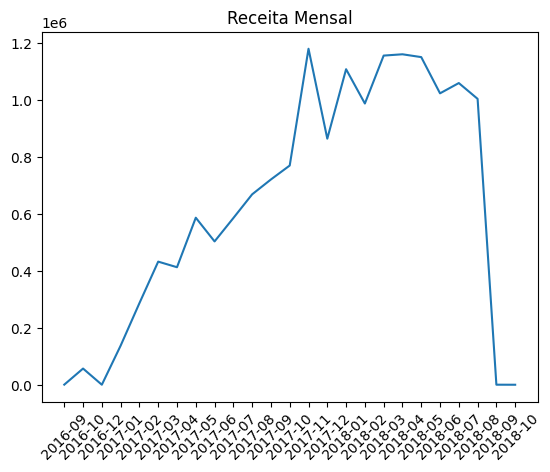

In [15]:
# Evolução de receita
plt.figure()
plt.plot(evolucao['month'].astype(str), evolucao['receita'])
plt.xticks(rotation=45)
plt.title('Receita Mensal')
plt.show()

### Gráfico de evolução Mensal da Receita

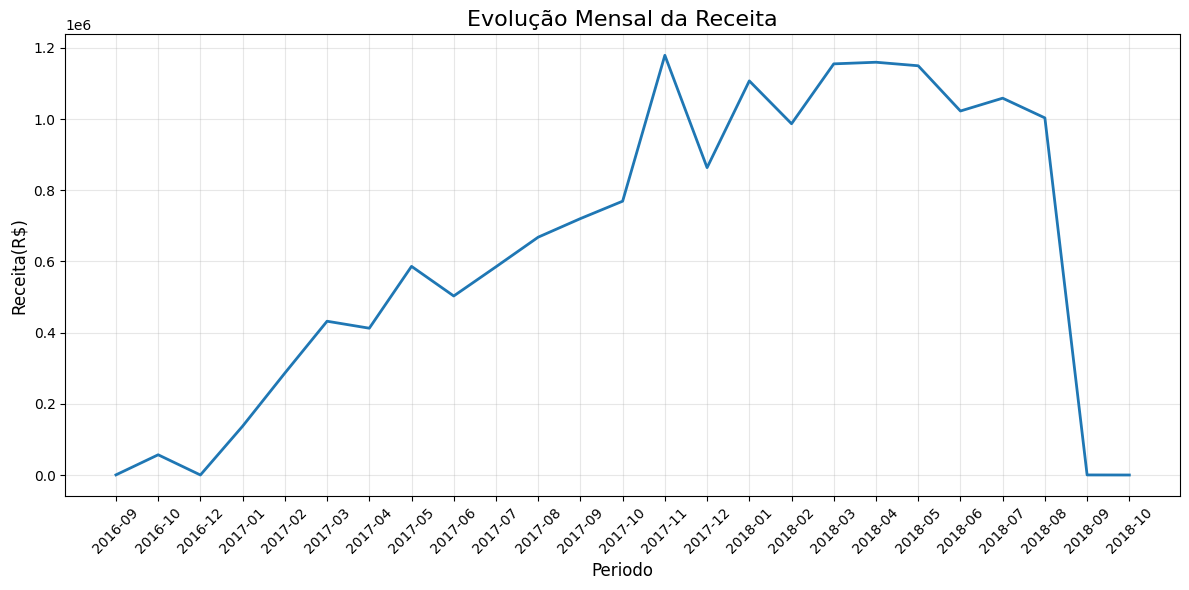

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(evolucao['month'], evolucao['receita'], linewidth=2)
plt.title('Evolução Mensal da Receita', fontsize=16)
plt.xlabel('Periodo', fontsize=12)
plt.ylabel('Receita(R$)', fontsize=12)

# Ajustando queda no final do gráfico
evolucao = evolucao[evolucao['receita'] > 0]

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Gráfico de Crescimento Percentual

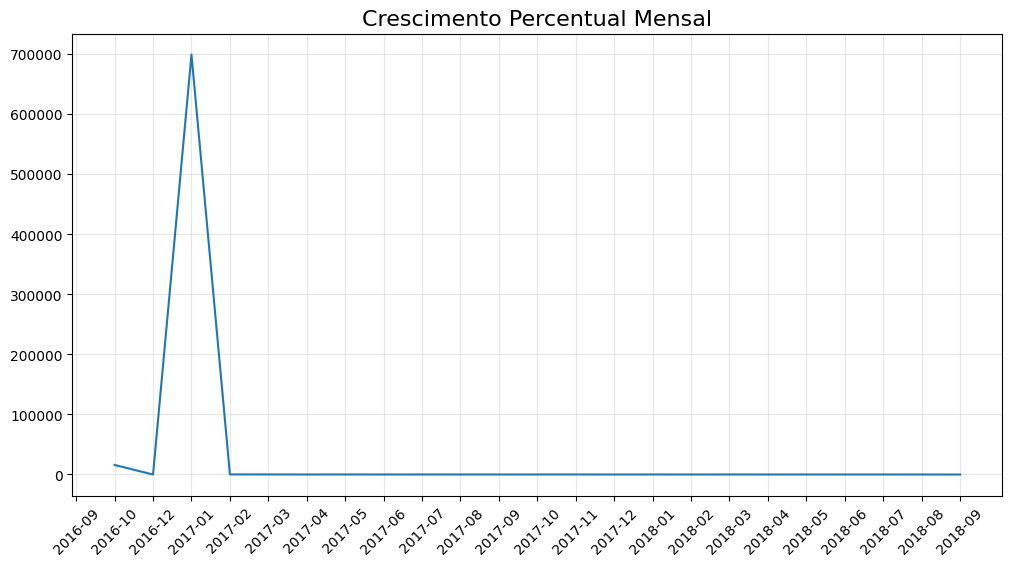

In [17]:
evolucao['crescimento_%'] = evolucao['receita'].pct_change() * 100

plt.figure(figsize=(12, 6))
plt.plot(evolucao['month'], evolucao['crescimento_%'])

plt.title('Crescimento Percentual Mensal', fontsize=16)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

### Top 10 Estados por Receita

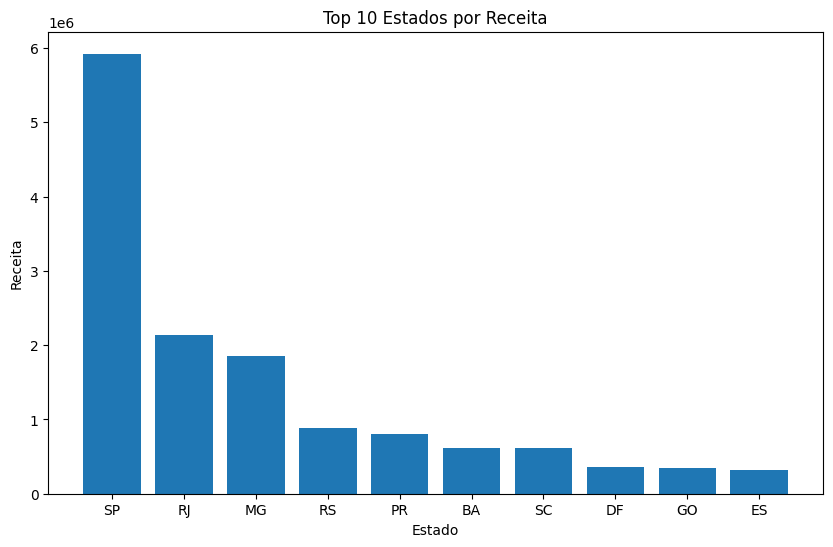

In [18]:
top_estados = receita_estado.sort_values(by='receita_item', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_estados['customer_state'], top_estados['receita_item'])

plt.title('Top 10 Estados por Receita')
plt.xlabel('Estado')
plt.ylabel('Receita')

plt.show()

### Evolução completa com KPIs

In [19]:
evolucao = (
    df.groupby('month')
    .agg(
        pedidos = ('order_id', 'nunique'),
        receita = ('receita_item', 'sum'),
    )
    .reset_index()
)

evolucao['ticket_medio'] = evolucao['receita'] / evolucao['pedidos']

# Remover mês incompleto
evolucao = evolucao[evolucao['receita'] > 0]

### Gráfico principal (refinado)

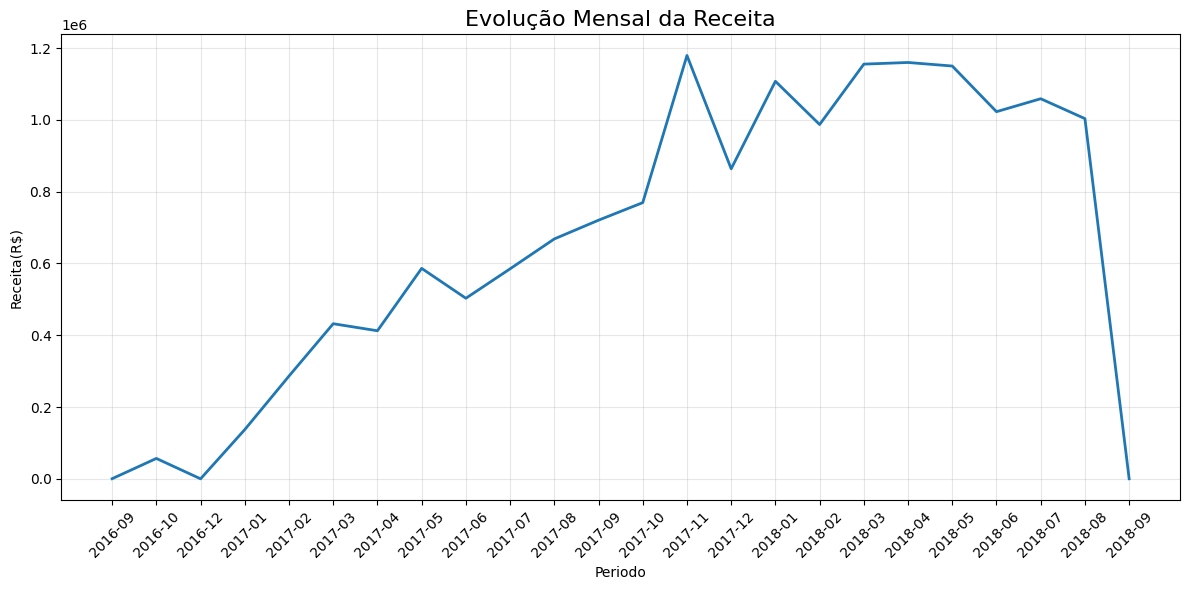

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(evolucao['month'], evolucao['receita'], linewidth=2)

plt.title('Evolução Mensal da Receita', fontsize=16)
plt.xlabel('Periodo')
plt.ylabel('Receita(R$)')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Estatística com valor

In [21]:
media = evolucao['receita'].mean()
mediana = evolucao['receita'].median()
desvio = evolucao['receita'].std()

print(f"Média: {media:,.0f}")
print(f"Mediana: {mediana:,.0f}")
print(f"Desvio padrão: {desvio:,.0f}")

Média: 660,148
Mediana: 694,302
Desvio padrão: 417,476


# 8. Estabilidade e volatilidade
#### Boxplot distribuição

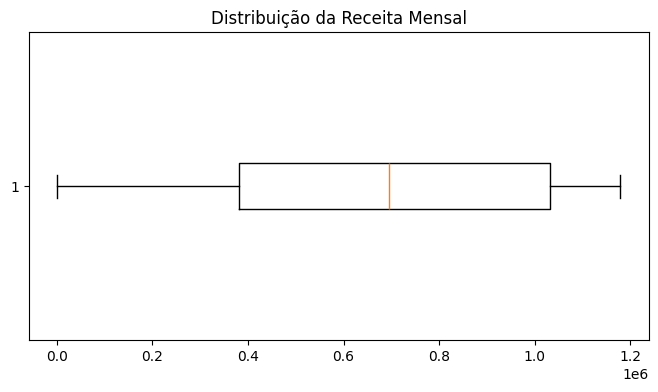

In [22]:
plt.figure(figsize=(8, 4))
plt.boxplot(evolucao['receita'], vert=False)
plt.title("Distribuição da Receita Mensal")
plt.show()

### Tendência (média móvel)

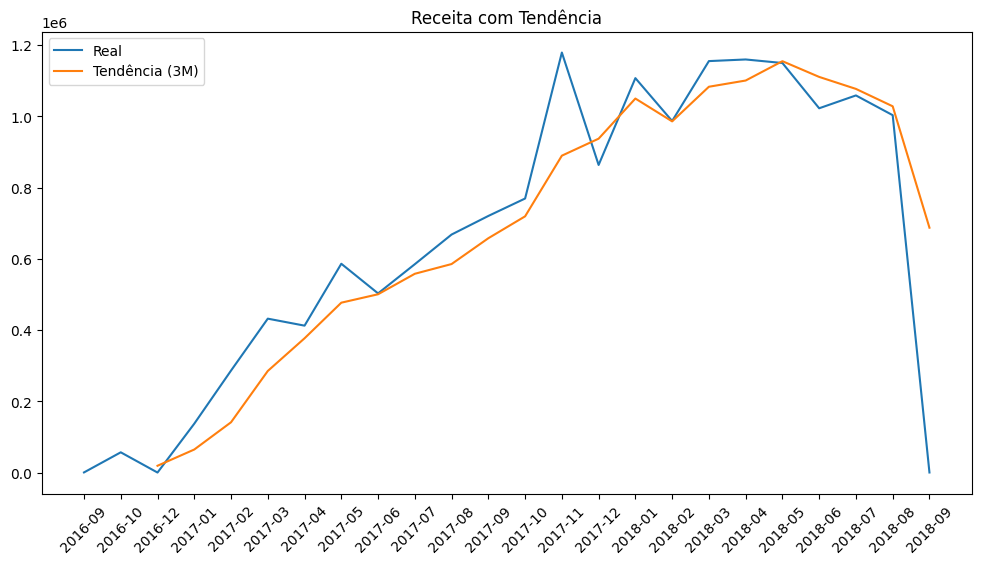

In [23]:
evolucao['media_movel'] = evolucao['receita'].rolling(3).mean()

plt.figure(figsize=(12, 6))
plt.plot(evolucao['month'], evolucao['receita'], label='Real')
plt.plot(evolucao['month'], evolucao['media_movel'], label='Tendência (3M)')

plt.legend()
plt.xticks(rotation=45)
plt.title("Receita com Tendência")
plt.show()

# 9. Drivers do crescimento

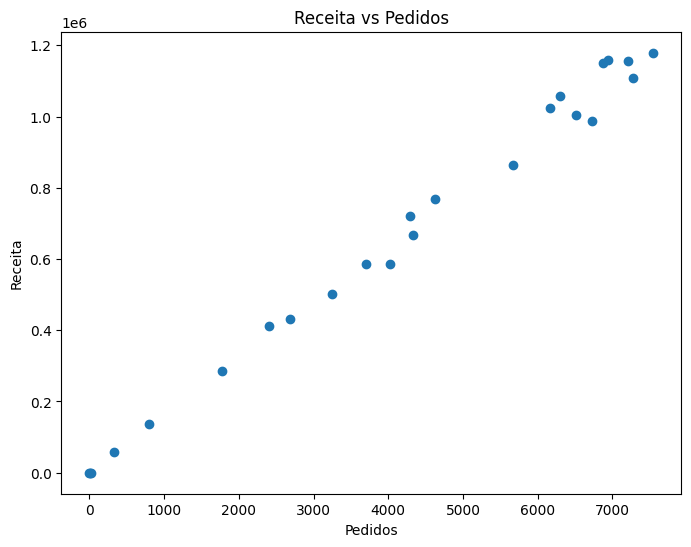

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(evolucao['pedidos'], evolucao['receita'])

plt.title("Receita vs Pedidos")
plt.xlabel('Pedidos')
plt.ylabel('Receita')
plt.show()

In [25]:
# Correlação
evolucao[['receita', 'pedidos', 'ticket_medio']].corr()

,receita,pedidos,ticket_medio
receita,1.000000,0.996120,0.530961
pedidos,0.996120,1.000000,0.515466
ticket_medio,0.530961,0.515466,1.000000


### Região (onde está o dinheiro)

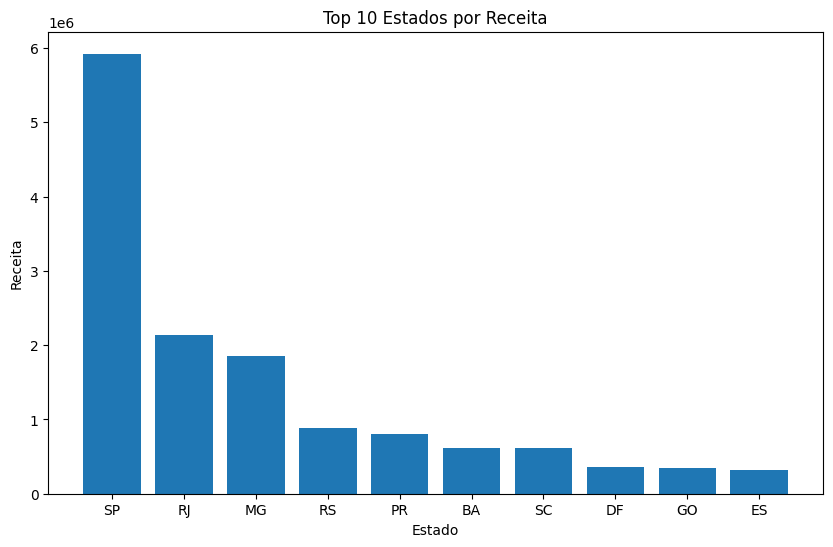

In [26]:
receita_estado = (
    df.groupby('customer_state')['receita_item']
    .sum()
    .reset_index()
    .sort_values(by='receita_item', ascending=False)
)

top10 = receita_estado.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10['customer_state'], top10['receita_item'])

plt.title('Top 10 Estados por Receita')
plt.xlabel('Estado')
plt.ylabel('Receita')

plt.show()

### Concentração

In [27]:
top5 = receita_estado.head(5)
participacao = top5['receita_item'].sum() / receita_estado['receita_item'].sum()
print(f"Top 5 estados representam {participacao:.2%} da receita total")

Top 5 estados representam 73.18% da receita total


# Gráficos finais

# 10. Crescimento da Receita

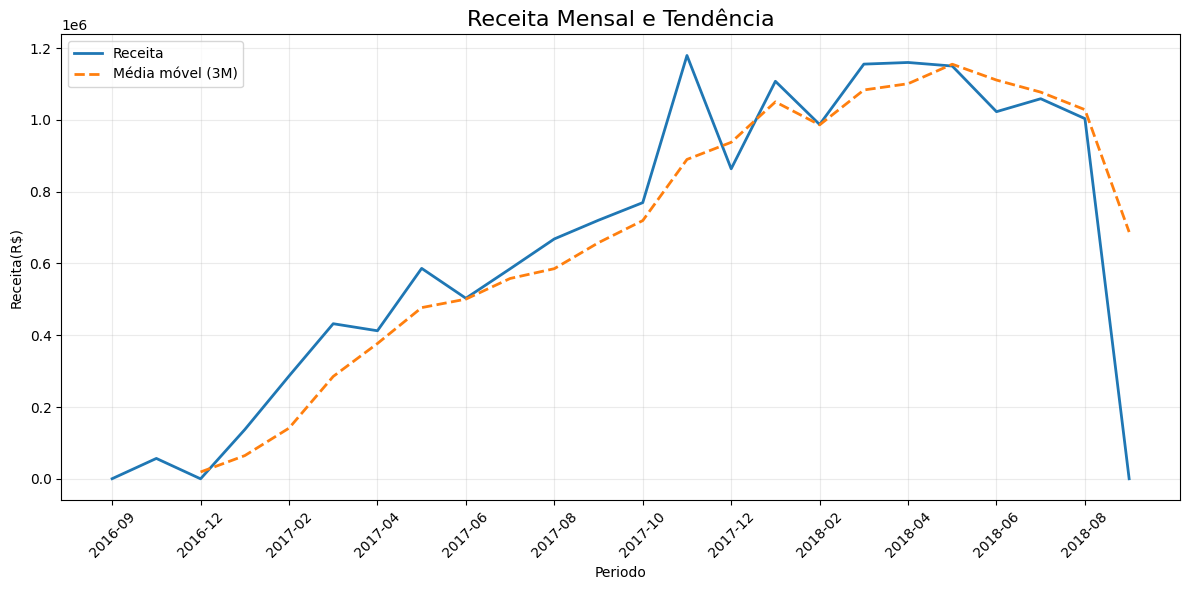

In [28]:
# Ordenando por mês
evolucao = evolucao.sort_values(by='month')

evolucao['mm_3'] = evolucao['receita'].rolling(3).mean()

plt.figure(figsize=(12, 6))
plt.plot(evolucao['month'], evolucao['receita'], linewidth=2, label='Receita')
plt.plot(evolucao['month'], evolucao['mm_3'], linewidth=2, linestyle='--', label='Média móvel (3M)')

# Reduzindo poluição do eixo X
idx = np.arange(len(evolucao))
plt.xticks(idx[::2], evolucao['month'].astype(str).iloc[::2], rotation=45)

plt.title('Receita Mensal e Tendência', fontsize=16)
plt.xlabel('Periodo')
plt.ylabel('Receita(R$)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

Observa-se crescimento consistente da receita ao longo do período, com um pico relevante em novembro de 2017, associado a eventos sazonais. Após esse momento, a operação passa a se estabilizar em um novo patamar acima de R$ 1 milhão.

# 11. Estabilidade e volatilidade
### Boxplot + estatística

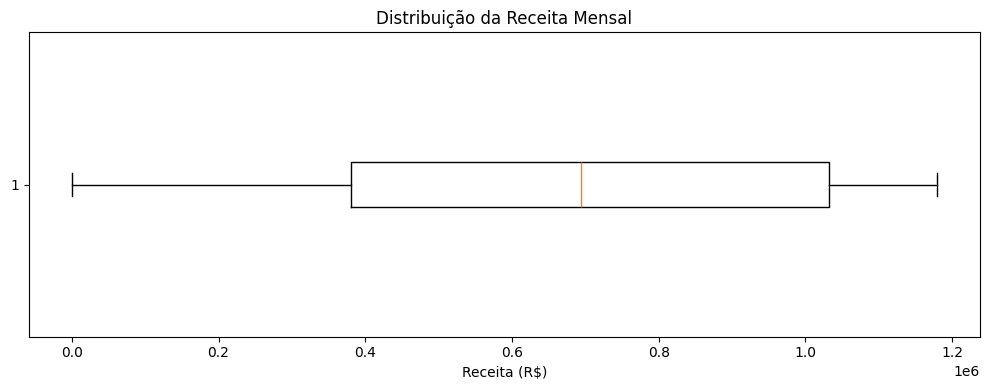

Média: 660,148 | Mediana: 694,302 | Desvio padrão: 417,476


In [29]:
media = evolucao['receita'].mean()
mediana = evolucao['receita'].median()
desvio = evolucao['receita'].std()

plt.figure(figsize=(10, 4))
plt.boxplot(evolucao['receita'], vert=False)
plt.title("Distribuição da Receita Mensal")
plt.xlabel('Receita (R$)')
plt.tight_layout()
plt.show()

print(f"Média: {media:,.0f} | Mediana: {mediana:,.0f} | Desvio padrão: {desvio:,.0f}")

# 12. Drivers do crescimento
### Receita vs Pedidos com regressão

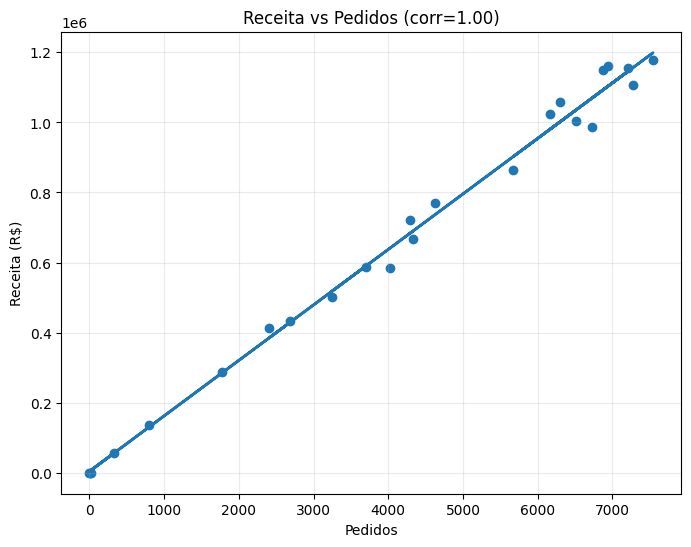

In [30]:
# Regressão simples
x = evolucao['pedidos'].values
y = evolucao['receita'].values
coef = np.polyfit(x, y, 1)
linha = np.poly1d(coef)

corr = evolucao[['receita', 'pedidos']].corr().iloc[0, 1]

plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.plot(x, linha(x), linewidth=2)
plt.title(f'Receita vs Pedidos (corr={corr:.2f})')
plt.xlabel('Pedidos')
plt.ylabel('Receita (R$)')
plt.grid(alpha=0.25)
plt.show()

A forte correlação entre receita e número de pedidos indica que o crescimento é impulsionado principalmente pelo volume, e não por aumento de ticket médio.

# 13. Concentração geográfica
### Região + Pareto

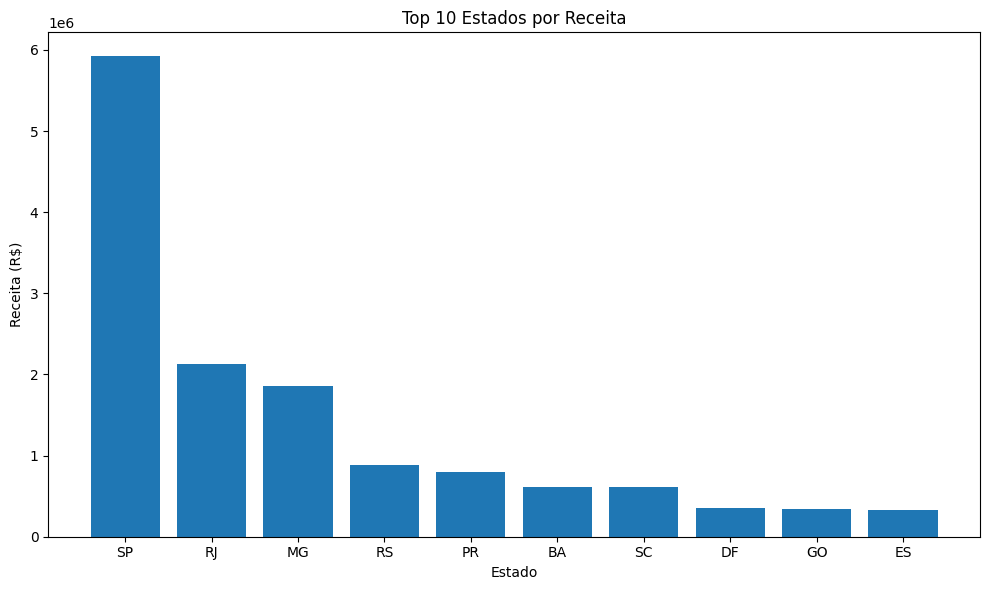

Top 5 estados representam 73.2% da receita total


In [31]:
receita_estado = (
    df.groupby('customer_state')['receita_item']
    .sum()
    .sort_values(ascending=False)
)

top10 = receita_estado.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10.index, top10.values)

plt.title('Top 10 Estados por Receita')
plt.xlabel('Estado')
plt.ylabel('Receita (R$)')
plt.tight_layout()
plt.show()

# Pareto (participação acumulada)
pareto = receita_estado.cumsum() / receita_estado.sum()
top5_share = receita_estado.head(5).sum() / receita_estado.sum()
print(f"Top 5 estados representam {top5_share:.1%} da receita total")

A receita apresenta forte concentração em poucos estados, especialmente São Paulo, indicando dependência regional relevante.

### Matriz de correlação

In [32]:
evolucao[['receita', 'pedidos', 'ticket_medio']].corr()

,receita,pedidos,ticket_medio
receita,1.000000,0.996120,0.530961
pedidos,0.996120,1.000000,0.515466
ticket_medio,0.530961,0.515466,1.000000


### Crescimento MoM (mês a mês)

In [33]:
evolucao['crescimento_%'] = evolucao['receita'].pct_change()*100

### Checagem de outliers

In [34]:
q1 = evolucao['receita'].quantile(0.25)
q3 = evolucao['receita'].quantile(0.75)
iqr = q3 - q1
outliers = evolucao[(evolucao['receita'] < q1 -1.5*iqr) | (evolucao['receita'] > q3 + 1.5*iqr)]
outliers

,month,pedidos,receita,ticket_medio,media_movel,mm_3,crescimento_%


In [35]:
# Checando intervalos 
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(q1, q3, iqr)
print(lower, upper)

380886.83499999996 1031689.84 650803.005
-595317.6725000001 2007894.3475000001


In [36]:
# Comparando
print(evolucao['receita'].min(), evolucao['receita'].max())

19.62 1179143.77


In [37]:
# Log evolução
evolucao['log_receita'] = np.log1p(evolucao['receita'])

q1 = evolucao['log_receita'].quantile(0.25)
q3 = evolucao['log_receita'].quantile(0.75)
iqr = q3 - q1

outliers = evolucao[
    (evolucao['log_receita'] < q1 - 1.5 * iqr) |
    (evolucao['log_receita'] > q3 + 1.5 * iqr)
]

In [38]:
from scipy.stats import zscore

evolucao['z'] = zscore(evolucao['receita'])

outliers = evolucao[abs(evolucao['z']) > 3]

print(evolucao['z'].describe())
print(evolucao[abs(evolucao['z']) > 3].shape)

count    2.400000e+01
mean    -2.405483e-16
std      1.021508e+00
min     -1.615245e+00
25%     -6.833145e-01
50%      8.356950e-02
75%      9.091125e-01
max      1.269912e+00
Name: z, dtype: float64
(0, 9)


In [39]:
evolucao.sort_values(by='receita', ascending=False)

,month,pedidos,receita,ticket_medio,media_movel,mm_3,crescimento_%,log_receita,z
13,2017-11,7544,1179143.77,156.302196,8.896183e+05,8.896183e+05,53.272431,13.980300,1.269912
18,2018-04,6939,1159698.04,167.127546,1.100578e+06,1.100578e+06,0.395733,13.963671,1.222331
17,2018-03,7211,1155126.82,160.189547,1.083113e+06,1.083113e+06,17.044922,13.959722,1.211146
19,2018-05,6873,1149781.82,167.289658,1.154869e+06,1.154869e+06,-0.855069,13.955084,1.198068
15,2018-01,7269,1107301.89,152.332080,1.049998e+06,1.049998e+06,28.227137,13.917438,1.094125
21,2018-07,6292,1058728.03,168.265739,1.077062e+06,1.077062e+06,3.525152,13.872580,0.975271
20,2018-06,6167,1022677.11,165.830568,1.110719e+06,1.110719e+06,-11.054681,13.837935,0.887060
22,2018-08,6512,1003308.47,154.070711,1.028238e+06,1.028238e+06,-5.234542,13.818815,0.839667
16,2018-02,6728,986908.96,146.686825,9.859194e+05,9.859194e+05,-10.872638,13.802334,0.799540
14,2017-12,5673,863547.23,152.220559,9.373345e+05,9.373345e+05,-26.764891,13.668805,0.497690


# Insigths de gráficos corporativos

# 1. Crescimento da receita
#### Este gráfico mostra que o negócio cresceu e passou a operar de forma consistente acima de um novo patamar, a linha de tendência reforça que, apesar das oscilações, a trajetória geral é de crescimento sustentável.

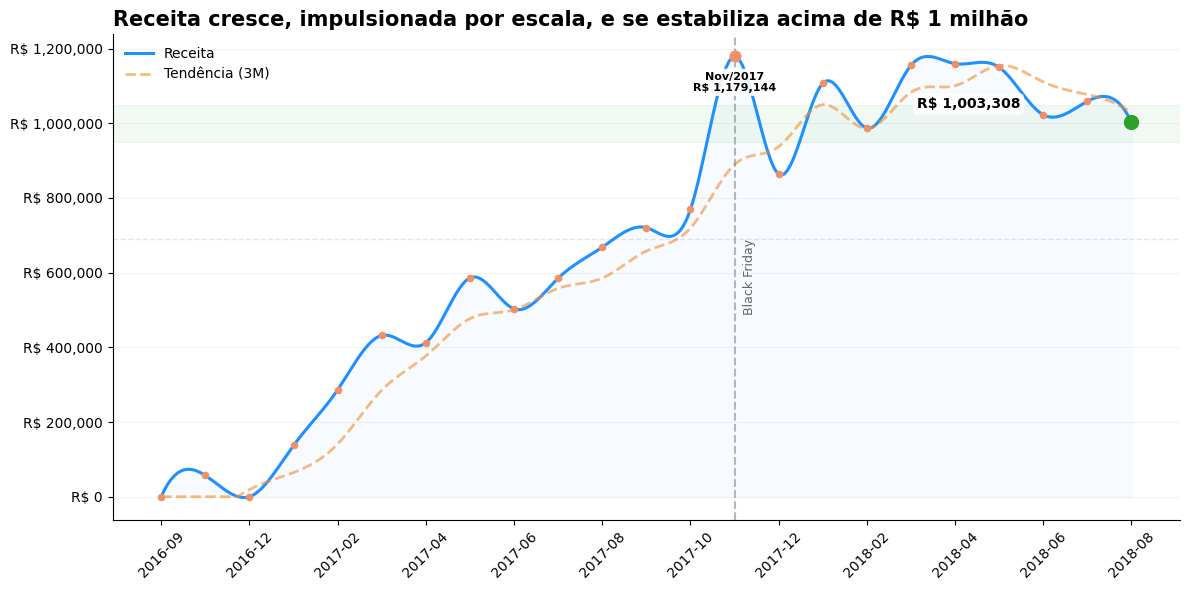

In [40]:
# Preparação dos dados
evolucao = evolucao.sort_values(by='month')

# Remove último mês (incompleto)
evolucao_plot = evolucao.iloc[:-1].copy().reset_index(drop=True)

x = np.arange(len(evolucao_plot))
y = evolucao_plot['receita'].values
media = y.mean()

# Suavização da receita
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y)(x_smooth)

# Média móvel (3 meses)
mask = ~np.isnan(evolucao_plot['mm_3'])
x_valid = x[mask]
y_mm_valid = evolucao_plot.loc[mask, 'mm_3'].values

if len(x_valid) > 3:
    y_mm_smooth = make_interp_spline(x_valid, y_mm_valid)(x_smooth)
else:
    y_mm_smooth = np.interp(x_smooth, x_valid, y_mm_valid)

y_mm_smooth = np.clip(y_mm_smooth, 0, None)

# Estilo
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 6))

bbox_style = dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9)

# Receita
ax.plot(x_smooth, y_smooth, linewidth=2.2, color='#1E90FF', label='Receita')
ax.fill_between(x_smooth, y_smooth, alpha=0.03, color='#1E90FF')

ax.scatter(x, y, s=20, color='#f19066', zorder=3)

# Tendência
ax.plot(
    x_smooth, y_mm_smooth,
    linestyle='--',
    linewidth=2,
    color='#f28e2b',
    alpha=0.6,
    label='Tendência (3M)'
)

# Média
ax.axhline(media, linestyle='--', linewidth=1, color='gray', alpha=0.2)

# Faixa de estabilização
ax.axhspan(950000, 1050000, color='#2ca02c', alpha=0.06)

# Último ponto
ultimo = evolucao_plot.iloc[-1]

ax.scatter(len(x)-1, ultimo['receita'], s=100, color='#2ca02c', zorder=5)

ax.annotate(
    f"R$ {ultimo['receita']:,.0f}",
    (len(x)-1, ultimo['receita']),
    textcoords='offset points',
    xytext=(-80, 10),
    ha='right',
    fontsize=10,
    fontweight='bold',
    bbox=bbox_style
)

# Pico simplificado
idx_pico = np.argmax(y)
pico_val = y[idx_pico]
mes_pico = pd.to_datetime(evolucao_plot['month'].iloc[idx_pico]).strftime('%b/%Y')

ax.scatter(idx_pico, pico_val, s=60, color='#f19066', zorder=6)

ax.annotate(
    f"{mes_pico}\nR$ {pico_val:,.0f}",
    (idx_pico, pico_val),
    textcoords='offset points',
    xytext=(0, -25),
    ha='center',
    fontsize=8,
    fontweight='bold',
    bbox=bbox_style
)

# Evento Black Friday
bf_mask = evolucao_plot['month'].astype(str) == '2017-11'

if bf_mask.any():
    bf_idx = evolucao_plot[bf_mask].index[0]

    ax.axvline(
        x=bf_idx,
        linestyle='--',
        color='#888888',
        alpha=0.6,
        linewidth=1.5
    )

ax.annotate(
    'Black Friday',
    (bf_idx + 0.2, (ax.get_ylim()[0] + ax.get_ylim()[1]) / 2),
    ha='left',
    va='center',
    fontsize=9,
    fontweight='normal',
    rotation=90,
    color='#666666'
)

# Eixos
ax.set_xticks(x[::2])
ax.set_xticklabels(
    evolucao_plot['month'].astype(str).iloc[::2],
    rotation=45
)

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'R$ {v:,.0f}')
)

# Finalização
ax.set_title(
    'Receita cresce, impulsionada por escala, e se estabiliza acima de R$ 1 milhão',
    fontsize=15,
    weight='bold',
    loc='left'
)

ax.set_ylabel('')
ax.set_xlabel('')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', alpha=0.15)
ax.grid(axis='x', visible=False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Insight: ganho de escala + mudança de patamar.

Observa-se crescimento consistente da receita ao longo do período, com um pico relevante em novembro de 2017, associado a eventos sazonais como a Black Friday.
Após esse momento, a operação passa a se estabilizar em um novo patamar de receita, indicando maturidade do negócio. Mais importante que o pico, é o fato de a receita não voltar ao nível anterior depois dele.

**Conclusão**

*A receita apresenta trajetória crescente ao longo do período, com indícios de transição para um patamar mais elevado nos meses finais.*

**Recomendação**

*Monitorar a consistência desse novo patamar nos períodos subsequentes, validando se a tendência observada se sustenta no longo prazo.*

# 2. Evolução mensal da receita (média móvel)
#### Este gráfico mostra que o crescimento deixou de ser instável e passou a ser consistente, a linha da média móvel reforça essa estabilização, mostrando redução de oscilações ao longo do tempo.

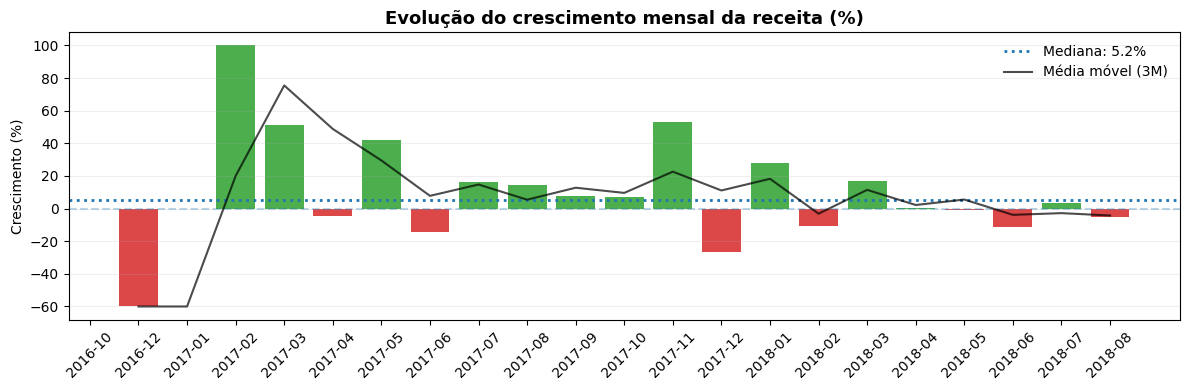

In [41]:
# Preparando os dados
evolucao_plot = evolucao.sort_values(by='month').iloc[:-1].copy()

# Crescimento percentual mês a mês
evolucao_plot['crescimento_%'] = evolucao_plot['receita'].pct_change() * 100

# Remove distorções causadas por base muito baixa
evolucao_plot.loc[
    evolucao_plot['receita'].shift(1) < 1000,
    'crescimento_%'
] = np.nan

# Limita extremos para melhorar leitura (evita distorção visual)
evolucao_plot['crescimento_%'] = evolucao_plot['crescimento_%'].clip(-60, 100)

# Tendência suavizada (média móvel 3 meses)
evolucao_plot['crescimento_suave'] = (
    evolucao_plot['crescimento_%']
    .rolling(3, min_periods=1)
    .mean()
)

# Mediana
mediana = evolucao_plot['crescimento_%'].median()

# Plot
fig, ax = plt.subplots(figsize=(12, 4))

# Cores (verde positivo, vermelho negativo)
cores = ['#2ca02c' if v >= 0 else '#d62728' for v in evolucao_plot['crescimento_%']]

# Barras
ax.bar(
    evolucao_plot['month'],
    evolucao_plot['crescimento_%'],
    color=cores,
    alpha=0.85
)

# Linha zero
ax.axhline(0, linestyle='--', alpha=0.3)

# Linha da mediana
ax.axhline(
    mediana,
    linestyle=':',
    linewidth=2,
    color='#1f77b4',
    label=f'Mediana: {mediana:.1f}%'
)

# Linha de tendência (média móvel)
ax.plot(
    evolucao_plot['month'],
    evolucao_plot['crescimento_suave'],
    color='black',
    linewidth=1.5,
    alpha=0.7,
    label='Média móvel (3M)'
)

# Estilo final 
ax.set_title(
    'Evolução do crescimento mensal da receita (%)',
    fontsize=13,
    weight='bold'
)

ax.set_ylabel('Crescimento (%)')
ax.set_xlabel('')

ax.grid(axis='y', alpha=0.2)
ax.legend(frameon=False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: Transição de crescimento caótico → crescimento controlado.

A análise do crescimento mensal evidencia elevada volatilidade nos períodos iniciais, influenciada por uma base reduzida de receita.

Ao longo do tempo, observa-se redução da variabilidade e convergência para taxas de crescimento mais estáveis, com mediana próxima de 5%, indicando maior previsibilidade operacional.

**Conclusão**

*Observa-se crescimento consistente da receita, com presença de um pico sazonal relevante e posterior estabilização em níveis mais elevados.*

**Recomendação**

*Explorar eventos sazonais como alavancas estratégicas de crescimento, ao mesmo tempo em que se busca reduzir a dependência desses picos para garantir maior estabilidade.*

# 3. Desvio da média
#### Este gráfico mostra quando o negócio deixou de ser abaixo da média e passou a operar consistentemente acima dela.

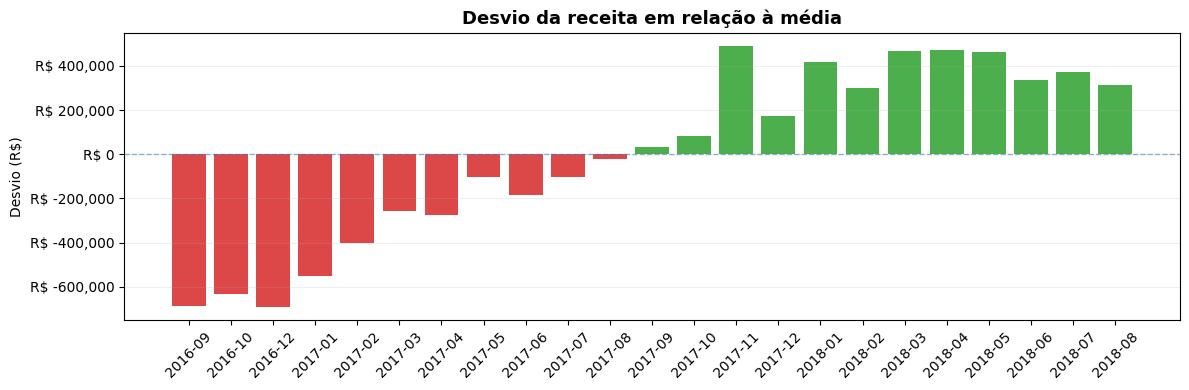

In [42]:
# Desvio em relação a média
# Cálculo do desvio
evolucao_plot['desvio_media'] = evolucao_plot['receita'] - media

# Plot
fig, ax = plt.subplots(figsize=(12, 4))

# Cores (acima da média = verde, abaixo = vermelho)
cores = ['#2ca02c' if v >= 0 else '#d62728' for v in evolucao_plot['desvio_media']]

ax.bar(
    evolucao_plot['month'],
    evolucao_plot['desvio_media'],
    color=cores,
    alpha=0.85
)

# Linha da média
ax.axhline(0, linestyle='--', alpha=0.5, linewidth=1)

# Estilo
ax.set_title(
    'Desvio da receita em relação à média',
    fontsize=13,
    weight='bold'
)

ax.set_ylabel('Desvio (R$)')
ax.set_xlabel('')

ax.grid(axis='y', alpha=0.2)

# Formatação monetária
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'R$ {v:,.0f}')
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A análise do desvio da receita em relação à média permite identificar períodos em que o desempenho ficou acima ou abaixo do nível médio observado.

Nos períodos iniciais, predominam valores negativos, refletindo a fase inicial de crescimento. A partir de 2017, observa-se maior recorrência de desvios positivos, indicando a consolidação do negócio em um patamar superior de receita.

**Conclusão**

*O crescimento apresenta alta volatilidade nos períodos iniciais, seguido de estabilização em taxas moderadas, indicando maior maturidade operacional.*

**Recomendação**

*Focar na manutenção de crescimento sustentável, priorizando previsibilidade em detrimento de variações abruptas.*

# 4. Volatilidade
#### Este gráfico mostra que a variabilidade da receita diminui ao longo do tempo, indicando que a operação ficou mais previsível e estável.

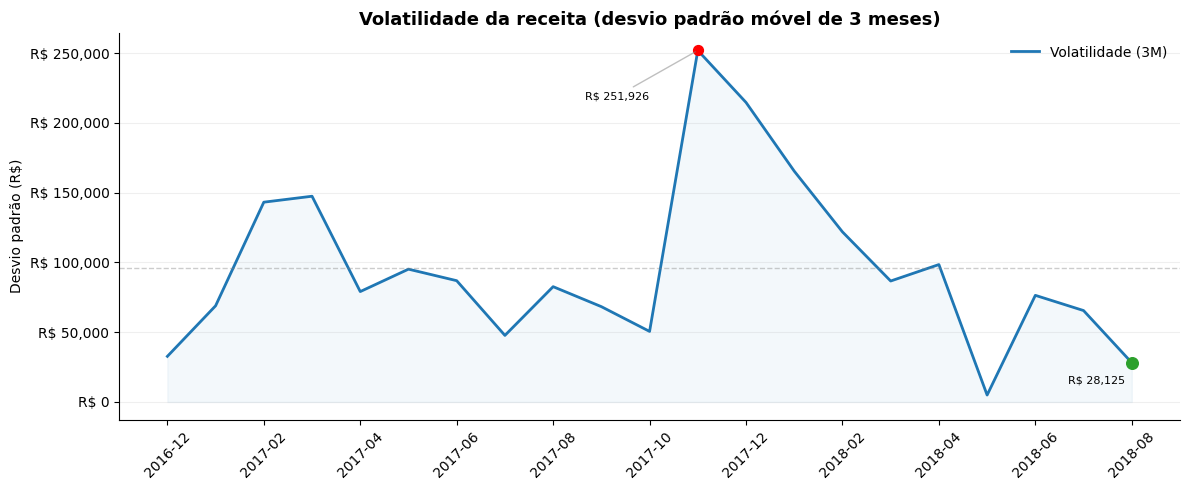

In [43]:
# Volatilidade da receita

# Preparação
evolucao = evolucao.sort_values(by='month')
evolucao_plot = evolucao.iloc[:-1].copy()

# Volatilidade (desvio padrão móvel 3 meses)
evolucao_plot['volatilidade'] = evolucao_plot['receita'].rolling(3).std()

# Remove NaN
df_vol = evolucao_plot.dropna(subset=['volatilidade']).copy()

# Eixo numérico
x = np.arange(len(df_vol))
y = df_vol['volatilidade'].values

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

# Linha principal (sem suavização artificial)
ax.plot(
    x,
    y,
    linewidth=2,
    color='#1f77b4',
    label='Volatilidade (3M)'
)

# Área leve
ax.fill_between(
    x,
    y,
    alpha=0.05,
    color='#1f77b4'
)

# Pico de volatilidade
idx_pico = np.argmax(y)
pico_val = y[idx_pico]

ax.scatter(
    idx_pico,
    pico_val,
    color='red',
    s=50,
    zorder=3
)

ax.annotate(
    f"R$ {pico_val:,.0f}",
    (idx_pico, pico_val),
    textcoords='offset points',
    xytext=(-35, -35), # Movendo levemente para a esquerda
    ha='right',
    fontsize=8,
    arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5) # Colocando uma linha de indicação
)

# Valor atual
ultimo_val = y[-1]

ax.scatter(
    len(x)-1,
    ultimo_val,
    color='#2ca02c',
    s=70,
    zorder=3
)

ax.annotate(
    f"R$ {ultimo_val:,.0f}",
    (len(x)-1, ultimo_val),
    textcoords='offset points',
    xytext=(-5, -15),  # Movendo levemente para a esquerda
    ha='right',
    fontsize=8
)

# Linha média (discreta)
media = y.mean()

ax.axhline(
    media,
    linestyle='--',
    linewidth=1,
    alpha=0.4,
    color='gray'
)

# Estilo
ax.set_title(
    'Volatilidade da receita (desvio padrão móvel de 3 meses)',
    fontsize=13,
    weight='bold'
)

ax.set_ylabel('Desvio padrão (R$)')
ax.set_xlabel('')

# Eixo X
ax.set_xticks(x[::2])
ax.set_xticklabels(df_vol['month'].astype(str).iloc[::2], rotation=45)

# Formatação monetária
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'R$ {v:,.0f}')
)

# Grid leve
ax.grid(axis='y', alpha=0.2)

# Remove bordas
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

A volatilidade da receita, medida pelo desvio padrão móvel de três meses, apresenta redução ao longo do tempo.

Observa-se maior variabilidade nos períodos iniciais, seguida por diminuição progressiva, indicando aumento da previsibilidade operacional e maior estabilidade da receita.

**Conclusão**

*A volatilidade reduz ao longo do tempo, evidenciando aumento da estabilidade e previsibilidade da operação.*

**Recomendação**

*Manter práticas operacionais que favoreçam estabilidade, reduzindo riscos associados a oscilações de receita.*

# 5. Distribuição de receita

#### A distribuição deste grágfico mostra que a receita deixou de se concentrar em valores baixos e passou a se concentrar em níveis mais altos, indicando que o negócio consolidou um novo patamar de faturamento.

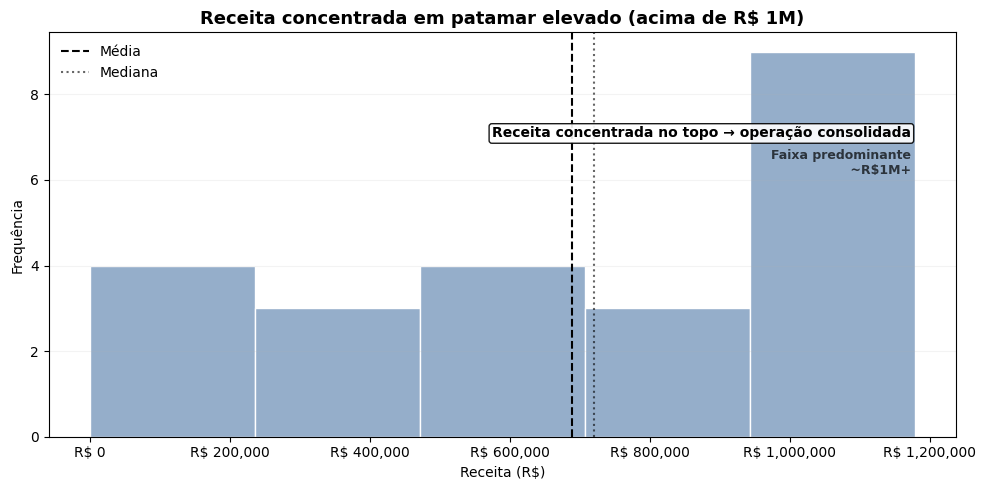

In [44]:
# Distribuição
plt.figure(figsize=(10, 5))

cor = '#4e79a7'

# Histograma
sns.histplot(
    evolucao_plot['receita'],
    bins=5,
    color=cor,
    alpha=0.6,
    edgecolor='white'
)

# Métricas
media = evolucao_plot['receita'].mean()
mediana = evolucao_plot['receita'].median()

# Linhas de referência
plt.axvline(
    media,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Média'
)

plt.axvline(
    mediana,
    color='black',
    linestyle=':',
    linewidth=1.5,
    alpha=0.6,
    label=f'Mediana'
)
# Destacar faixa de alto faturamento
plt.text(
    0.95, 0.65,
    'Faixa predominante\n ~R$1M+',
    transform=plt.gca().transAxes,
    ha='right',
    fontsize=9,
    fontweight='bold',
    alpha=0.7
)

# Destacar a faixa da receita concentrada no topo
plt.text(
    0.95, 0.74,
    'Receita concentrada no topo → operação consolidada',
    transform=plt.gca().transAxes,
    ha='right',
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.9)
)

# Estilo
plt.title('Receita concentrada em patamar elevado (acima de R$ 1M)', fontsize=13, weight='bold')
plt.xlabel('Receita (R$)')
plt.ylabel('Frequência')

plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'R$ {v:,.0f}')
)

plt.grid(axis='y', alpha=0.15)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

Insight: A receita deixou de ser volátil e passou a se concentrar consistentemente acima de R$1 milhão, indicando consolidação do negócio em um novo patamar.

A distribuição da receita apresenta assimetria à direita, com maior concentração em valores elevados.

A proximidade entre média e mediana indica redução da dispersão nos períodos mais recentes, reforçando a consolidação do negócio em um novo patamar de receita.

A distribuição deixa claro que o crescimento não foi pontual — houve uma mudança estrutural de patamar.

**Conclusão**

*A receita passa de um comportamento predominantemente abaixo da média para acima da média ao longo do tempo, indicando mudança de patamar.*

**Recomendação**

*Consolidar esse novo nível de operação, garantindo que o desempenho acima da média se mantenha consistente.*

# 6. Evolução da receita
#### Esse gráfico mostra a evolução inicial da receita ao longo do tempo. Ele serve como ponto de partida da análise, permitindo visualizar o crescimento e identificar mudanças de patamar antes da aplicação de métricas mais avançadas.

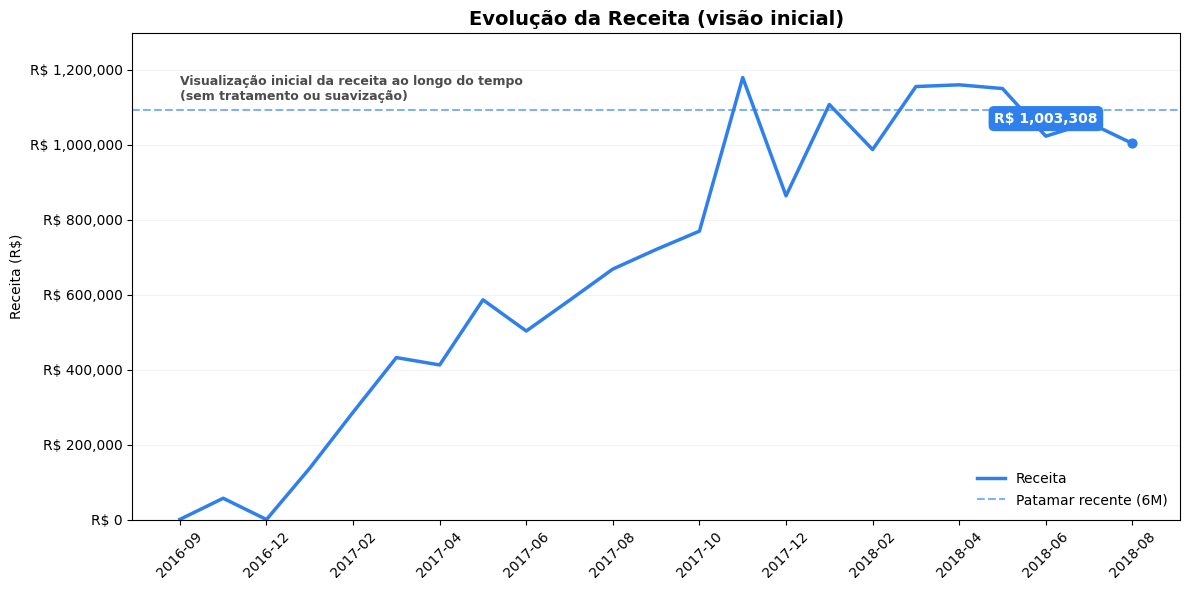

In [45]:
# Evolução bruta da receita
# Ordenação
df = evolucao.sort_values(by='month').copy()

# Remoção de mês incompleto (regra simples)
if df['receita'].iloc[-1] < df['receita'].iloc[-2] * 0.8:
    df = df.iloc[:-1]

# Eixos
x = np.arange(len(df))
y = df['receita'].values

# Média recente (últimos 6 meses)
media_recente = df['receita'].tail(6).mean()

# Plot
plt.figure(figsize=(12,6))

# Linha principal (sem suavização)
plt.plot(
    x, y,
    linewidth=2.5,
    color='#2F80ED',
    label='Receita'
)

# Linha de patamar (últimos meses)
plt.axhline(
    media_recente,
    linestyle='--',
    linewidth=1.5,
    alpha=0.6,
    color='#2F80ED',
    label='Patamar recente (6M)'
)

# Último ponto
ultimo_valor = y[-1]

plt.scatter(
    len(df)-1,
    ultimo_valor,
    color='#2F80ED',
    s=40,
    zorder=5
)

plt.annotate(
    f'R$ {ultimo_valor:,.0f}',
    xy=(len(df)-1, ultimo_valor),
    xytext=(-25, 15),
    textcoords='offset points',
    ha='right',
    fontsize=10,
    fontweight='bold',
    color='white',
    bbox=dict(
        boxstyle='round,pad=0.4',
        fc='#2F80ED',
        ec='none'
    )
)

# Formatação
plt.title(
    'Evolução da Receita (visão inicial)',
    fontsize=14,
    weight='bold'
)

plt.ylabel('Receita (R$)')

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f'R$ {v:,.0f}')
)

plt.xticks(
    x[::2],
    df['month'].astype(str).iloc[::2],
    rotation=45
)

plt.grid(axis='y', alpha=0.15)
plt.legend(frameon=False)

plt.ylim(0, y.max()*1.1)

# Contexto
plt.text(
    0,
    y.max()*0.95,
    'Visualização inicial da receita ao longo do tempo\n(sem tratamento ou suavização)',
    fontsize=9,
    fontweight='bold',
    alpha=0.7
)

plt.tight_layout()
plt.show()

A receita apresenta crescimento ao longo do período, com indícios de consolidação em um novo patamar nos meses finais.

**Conclusão**

*A distribuição da receita apresenta concentração em valores mais elevados, com redução da dispersão e maior proximidade entre média e mediana.*

**Recomendação**

*Explorar estratégias que sustentem esse nível de receita, garantindo continuidade da operação em patamares mais altos.*

# 7. Linha de pedidos ao longo do tempo
#### Este gráfico tem como objetivo identificar o principal driver da receita, distinguindo crescimento por volume de pedidos versus variação de preço.


In [46]:
# converter data
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# merge
df = orders.merge(orders_items, on='order_id')

# criar mês
df['mes'] = df['order_purchase_timestamp'].dt.to_period('M')

# receita correta
df['receita_item'] = df['price'] + df['freight_value']

# agregação
resultado = df.groupby('mes').agg(
    pedidos=('order_id', 'nunique'),
    receita=('receita_item', 'sum')
).reset_index()

# ticket médio
resultado['ticket_medio'] = resultado['receita'] / resultado['pedidos']

# ordenar
resultado = resultado.sort_values('mes')

print(resultado)

        mes  pedidos     receita  ticket_medio
0   2016-09        3      354.75    118.250000
1   2016-10      308    56808.84    184.444286
2   2016-12        1       19.62     19.620000
3   2017-01      789   137188.49    173.876413
4   2017-02     1733   286280.62    165.193664
5   2017-03     2641   432048.59    163.592802
6   2017-04     2391   412422.24    172.489435
7   2017-05     3660   586190.95    160.161462
8   2017-06     3217   502963.04    156.345365
9   2017-07     3969   584971.62    147.385140
10  2017-08     4293   668204.60    155.649802
11  2017-09     4243   720398.91    169.785272
12  2017-10     4568   769312.37    168.413391
13  2017-11     7451  1179143.77    158.253090
14  2017-12     5624   863547.23    153.546805
15  2018-01     7220  1107301.89    153.365913
16  2018-02     6694   986908.96    147.431873
17  2018-03     7188  1155126.82    160.702117
18  2018-04     6934  1159698.04    167.248059
19  2018-05     6853  1149781.82    167.777881
20  2018-06  

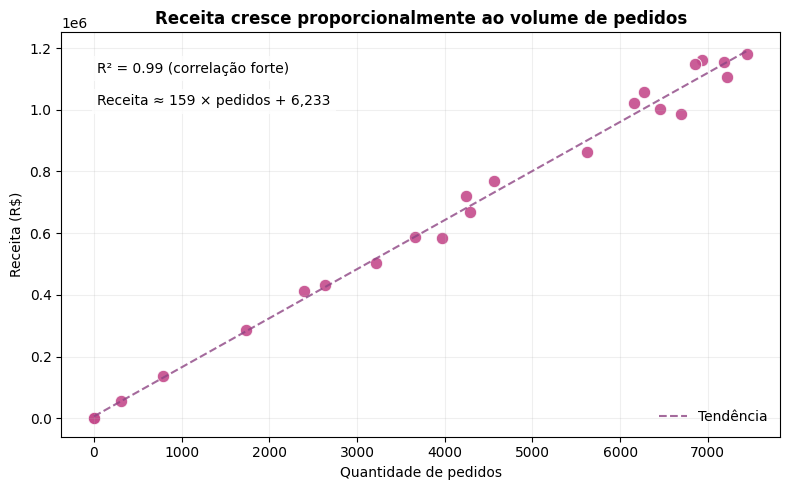

In [47]:
# Remove inválidos
df_plot = resultado[resultado['pedidos'] > 0].copy()

# ordem cronológica (correção principal)
df_plot['mes'] = pd.to_datetime(df_plot['mes'].astype(str))
df_plot = df_plot.sort_values('mes')

x = df_plot['pedidos']
y = df_plot['receita']

fig, ax = plt.subplots(figsize=(8,5))

# Scatter (roxo)
ax.scatter(
    x, y,
    alpha=0.9,
    s=80,
    color='#C54B8C',  # Bolinhas
    edgecolor='white',
    linewidth=0.7
)

# Regressão
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_ord = np.sort(x)

ax.plot(
    x_ord,
    p(x_ord),
    linestyle='--',
    alpha=0.8,
    color='#8E4584', # Linhas
    label='Tendência'
)

# Coeficientes da regressão
a, b = z

# R²
y_pred = p(x)
r2 = 1 - (np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2))

ax.text(
    0.05,
    0.9,
    f'R² = {r2:.2f} (correlação forte)',
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)

ax.text(
    0.05,
    0.82,
    f'Receita ≈ {a:,.0f} × pedidos + {b:,.0f}',
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)

# Labels
ax.set_title('Receita cresce proporcionalmente ao volume de pedidos', weight='bold')
ax.set_xlabel('Quantidade de pedidos')
ax.set_ylabel('Receita (R$)')

ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

A análise evidencia uma forte relação linear entre pedidos e receita (R² = 0,99), indicando que o crescimento é predominantemente impulsionado pelo aumento do volume de pedidos. O coeficiente angular da regressão (~R$ 159 por pedido) sugere estabilidade no ticket médio, reforçando a previsibilidade da operação e caracterizando um modelo de crescimento baseado em escala.

**Conclusão**

*Existe forte relação linear entre pedidos e receita (R² ≈ 0,99), indicando que o crescimento é predominantemente impulsionado pelo volume de pedidos, com ticket médio estável.*

**Recomendação**

*Priorizar estratégias de aquisição e retenção de clientes, uma vez que o aumento de volume é o principal driver de crescimento. Iniciativas de aumento de ticket médio podem atuar como complemento, mas não como foco principal.*